example of using SDV to generate synthetic data based on the demographic and sruvey data from Eisenberg et al.

In [13]:
import sdv
import pandas as pd

from pathlib import Path

FIGURE_DIR = Path("../../book/book/images")

In [14]:
df_demographics = pd.read_csv('https://raw.githubusercontent.com/IanEisenberg/Self_Regulation_Ontology/refs/heads/master/Data/Complete_02-16-2019/demographics.csv', index_col=0).replace({'Sex': {0: 'Male', 1: 'Female'}})
variables_of_interest = ['Sex', 'Age', 'HighestEducation', 
       'HeightInches', 'WeightPounds','ArrestedChargedLifeCount',
       'CoffeeCupsPerDay', 'HouseholdIncome']
df_demographics = df_demographics[variables_of_interest]

df_measures = pd.read_csv('https://raw.githubusercontent.com/IanEisenberg/Self_Regulation_Ontology/refs/heads/master/Data/Complete_02-16-2019/meaningful_variables_clean.csv', index_col=0)
measures_of_interest = [
       'upps_impulsivity_survey.lack_of_perseverance',
       'upps_impulsivity_survey.lack_of_premeditation',
       'upps_impulsivity_survey.negative_urgency',
       'upps_impulsivity_survey.positive_urgency',
       'upps_impulsivity_survey.sensation_seeking',
        'ten_item_personality_survey.agreeableness',
       'ten_item_personality_survey.conscientiousness.ReflogTr',
       'ten_item_personality_survey.emotional_stability',
       'ten_item_personality_survey.extraversion',
       'ten_item_personality_survey.openness',
       'ravens.score',
       'cognitive_reflection_survey.correct_proportion'
]
df_measures = df_measures[measures_of_interest]
df_orig = df_demographics.join(df_measures, how='inner')


df_orig.head() 

,Sex,Age,HighestEducation,HeightInches,WeightPounds,ArrestedChargedLifeCount,CoffeeCupsPerDay,HouseholdIncome,upps_impulsivity_survey.lack_of_perseverance,upps_impulsivity_survey.lack_of_premeditation,upps_impulsivity_survey.negative_urgency,upps_impulsivity_survey.positive_urgency,upps_impulsivity_survey.sensation_seeking,ten_item_personality_survey.agreeableness,ten_item_personality_survey.conscientiousness.ReflogTr,ten_item_personality_survey.emotional_stability,ten_item_personality_survey.extraversion,ten_item_personality_survey.openness,ravens.score,cognitive_reflection_survey.correct_proportion
s001,Female,27,3,62,110,0.0,1.0,40000.0,1.5,1.909091,1.583333,2.142857,3.416667,4.5,0.916291,6.0,3.5,6.0,2.0,0.166667
s002,Male,35,2,72,240,0.0,3.0,19500.0,1.5,2.090909,3.000000,3.285714,3.083333,6.0,1.386294,6.0,5.0,6.5,4.0,0.166667
s003,Male,25,4,73,185,0.0,1.0,60000.0,2.4,2.363636,3.000000,2.785714,2.833333,5.5,0.916291,5.0,4.5,5.0,3.0,0.666667
s004,Male,35,4,71,190,0.0,0.0,81000.0,1.5,1.636364,1.583333,1.142857,1.916667,6.5,0.000000,7.0,3.0,4.0,9.0,0.666667
s005,Male,36,3,76,175,5.0,0.0,36000.0,1.7,1.363636,1.750000,1.000000,2.833333,6.0,1.098612,7.0,3.0,6.0,14.0,0.833333


In [15]:
# Create synthetic data with independent variables using SDV
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import Metadata
import numpy as np
import pandas as pd
import warnings

def generate_independent_synthetic_data(df, random_seed=42):
    """
    Generate synthetic data where all variables are independent.
    
    Uses SDV to model the full dataset, then shuffles each column 
    independently to break all correlations while preserving marginal distributions.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Original dataframe to generate synthetic version of
    random_seed : int, optional
        Random seed for reproducibility (default: 42)
        
    Returns:
    --------
    pd.DataFrame
        Synthetic dataframe with same shape and column names as input,
        but with independent variables
    """
    # Suppress the metadata saving warning
    warnings.filterwarnings('ignore', message='We strongly recommend saving the metadata')
    
    # Set random seed
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Create metadata for the full dataset
    metadata = Metadata.detect_from_dataframe(
        data=df,
        table_name='full_data'
    )
    
    # Create synthesizer for the full dataset
    synthesizer = GaussianCopulaSynthesizer(
        metadata,
        enforce_rounding=False,
        enforce_min_max_values=True,
        default_distribution='norm'
    )
    
    # Fit synthesizer to the full dataset
    synthesizer.fit(df)
    
    # Generate synthetic data
    df_synthetic = synthesizer.sample(num_rows=len(df))
    
    # CRITICAL: Shuffle each column independently to break all correlations
    # This preserves the marginal distribution of each variable but eliminates dependencies
    for col in df_synthetic.columns:
        shuffled_values = df_synthetic[col].values.copy()
        np.random.shuffle(shuffled_values)
        df_synthetic[col] = shuffled_values
    
    return df_synthetic


# Generate synthetic data
print("Generating synthetic data with independent variables using SDV...")
df_synthetic = generate_independent_synthetic_data(df_orig, random_seed=42)

print(f"\nOriginal data shape: {df_orig.shape}")
print(f"Synthetic data shape: {df_synthetic.shape}")
print("\nFirst few rows of synthetic data:")
df_synthetic.head()

Generating synthetic data with independent variables using SDV...

Original data shape: (522, 20)
Synthetic data shape: (522, 20)

First few rows of synthetic data:


,Sex,Age,HighestEducation,HeightInches,WeightPounds,ArrestedChargedLifeCount,CoffeeCupsPerDay,HouseholdIncome,upps_impulsivity_survey.lack_of_perseverance,upps_impulsivity_survey.lack_of_premeditation,upps_impulsivity_survey.negative_urgency,upps_impulsivity_survey.positive_urgency,upps_impulsivity_survey.sensation_seeking,ten_item_personality_survey.agreeableness,ten_item_personality_survey.conscientiousness.ReflogTr,ten_item_personality_survey.emotional_stability,ten_item_personality_survey.extraversion,ten_item_personality_survey.openness,ravens.score,cognitive_reflection_survey.correct_proportion
0,Female,33,4,73,190,0.0,1.0,26474.371529,1.877596,1.025765,2.279142,1.735841,3.163992,6.601295,0.155383,4.241843,1.703974,7.000000,6.283776,0.480148
1,Male,29,4,68,209,0.0,0.0,54314.723189,2.090224,2.329499,2.124844,1.506781,2.618777,4.566269,1.376290,6.164976,1.000000,5.096525,12.872991,1.000000
2,Female,37,3,65,258,0.0,0.0,502.449962,1.446387,1.000000,2.696730,1.783371,2.886117,7.000000,1.079865,1.769952,5.073215,6.019269,8.964215,0.353231
3,Female,39,4,77,218,6.0,2.0,1486.077714,2.045831,1.897125,2.896441,1.534041,1.654530,5.311547,1.113008,4.641103,1.337684,3.903379,18.000000,0.332411
4,Male,33,4,66,218,0.0,2.0,62506.730588,1.849723,1.846306,1.404208,2.550111,2.457319,5.540038,0.169969,2.882354,3.327014,2.585049,5.603175,0.079211


Original data correlations (first 5x5):
                            Age  HighestEducation  HeightInches  WeightPounds  \
Age                       1.000             0.099        -0.009         0.035   
HighestEducation          0.099             1.000         0.130        -0.034   
HeightInches             -0.009             0.130         1.000         0.327   
WeightPounds              0.035            -0.034         0.327         1.000   
ArrestedChargedLifeCount  0.070            -0.055         0.053        -0.002   

                          ArrestedChargedLifeCount  
Age                                          0.070  
HighestEducation                            -0.055  
HeightInches                                 0.053  
WeightPounds                                -0.002  
ArrestedChargedLifeCount                     1.000  

Synthetic data correlations (first 5x5):
                            Age  HighestEducation  HeightInches  WeightPounds  \
Age                       1.000 

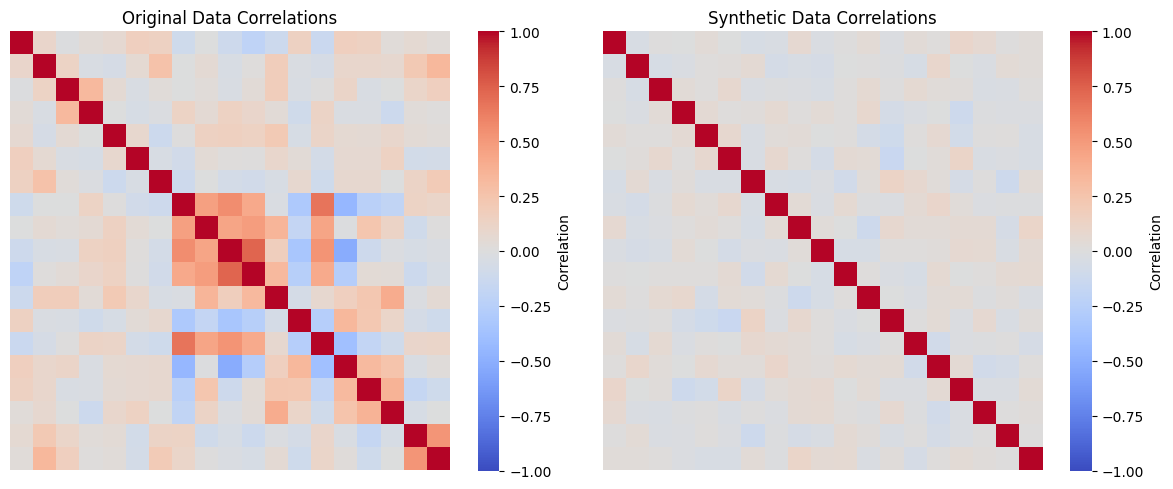

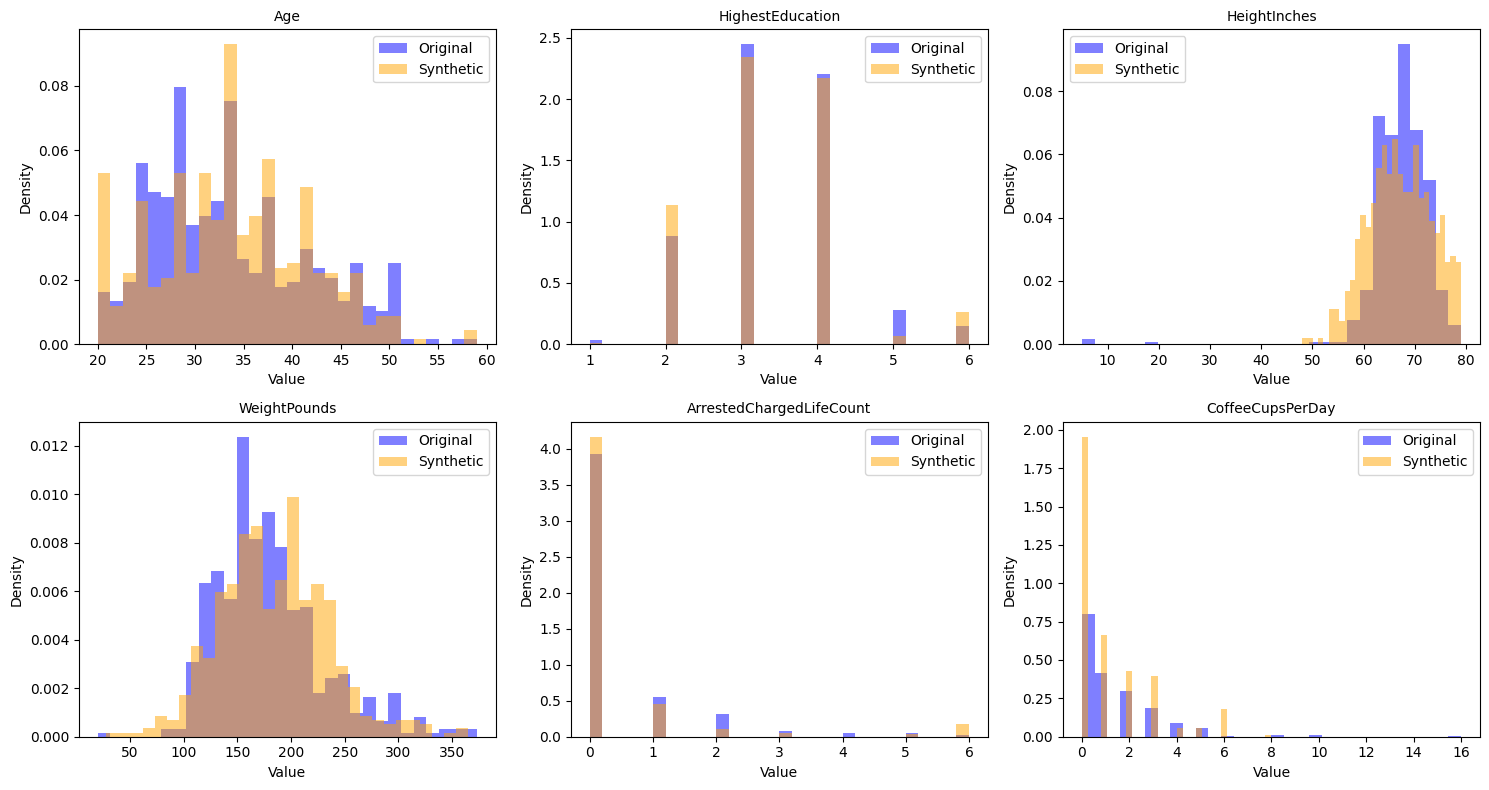


Summary statistics comparison for first few variables:

Age:
  Original: mean=33.63, std=7.88
  Synthetic: mean=33.78, std=7.78

HighestEducation:
  Original: mean=3.38, std=0.90
  Synthetic: mean=3.32, std=0.95

HeightInches:
  Original: mean=67.24, std=6.16
  Synthetic: mean=67.00, std=5.98


In [16]:
# Compare distributions and correlations between original and synthetic data
import matplotlib.pyplot as plt
import seaborn as sns

# Check that correlations are indeed minimal in synthetic data
numeric_orig = df_orig.select_dtypes(include=[np.number])
numeric_synth = df_synthetic.select_dtypes(include=[np.number])

print("Original data correlations (first 5x5):")
print(numeric_orig.corr().iloc[:5, :5].round(3))
print("\nSynthetic data correlations (first 5x5):")
print(numeric_synth.corr().iloc[:5, :5].round(3))

# plot correlation matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(numeric_orig.corr(), ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, 
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Correlation'})
axes[0].set_title('Original Data Correlations')
sns.heatmap(numeric_synth.corr(), ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Correlation'})
axes[1].set_title('Synthetic Data Correlations')
plt.tight_layout()
plt.savefig(FIGURE_DIR / "sdv_correlations.png")

# Visualize distributions of a few variables
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

numeric_cols = numeric_orig.columns[:6]

for i, col in enumerate(numeric_cols):
    if col in df_synthetic.columns:
        orig_data = df_orig[col].dropna()
        synth_data = df_synthetic[col].dropna()
        
        axes[i].hist(orig_data, alpha=0.5, label='Original', bins=30, density=True, color='blue')
        axes[i].hist(synth_data, alpha=0.5, label='Synthetic', bins=30, density=True, color='orange')
        axes[i].set_title(col, fontsize=10)
        axes[i].legend()
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Density')

plt.tight_layout()
plt.savefig(FIGURE_DIR / "sdv_distributions.png")
plt.show()

# Print summary statistics comparison
print("\n" + "="*80)
print("Summary statistics comparison for first few variables:")
print("="*80)
for col in numeric_cols[:3]:
    print(f"\n{col}:")
    print(f"  Original: mean={df_orig[col].mean():.2f}, std={df_orig[col].std():.2f}")
    print(f"  Synthetic: mean={df_synthetic[col].mean():.2f}, std={df_synthetic[col].std():.2f}")

In [17]:
df_orig[['HouseholdIncome', 'cognitive_reflection_survey.correct_proportion']].corr()

,HouseholdIncome,cognitive_reflection_survey.correct_proportion
HouseholdIncome,1.000000,0.197884
cognitive_reflection_survey.correct_proportion,0.197884,1.000000


In [18]:
from scipy.stats import spearmanr


# Compute correlation and p-value for HouseholdIncome and cognitive_reflection_survey.correct_proportion
col1 = 'HouseholdIncome'
col2 = 'cognitive_reflection_survey.correct_proportion'

# Drop NaN values for the correlation calculation
data = df_orig[[col1, col2]].dropna()

# Compute Pearson correlation and p-value
corr, pval = spearmanr(data[col1], data[col2])

print(f"Correlation between {col1} and {col2}:")
print(f"  Spearman r = {corr:.4f}")
print(f"  p-value = {pval:.5f}")
print(f"  n = {len(data)}")

Correlation between HouseholdIncome and cognitive_reflection_survey.correct_proportion:
  Spearman r = 0.1617
  p-value = 0.00021
  n = 522


In [ ]:
# perform randomization analysis to confirm significance

n_permutations = 10000
observed_corr, _ = spearmanr(data[col1], data[col2])
# include observed corr to ensure that p is not zero
permuted_corrs = [observed_corr]
for _ in range(n_permutations):
    shuffled_col2 = data[col2].sample(frac=1, replace=False).values
    permuted_corr, _ = spearmanr(data[col1], shuffled_col2)
    permuted_corrs.append(permuted_corr)

p_value_randomization = np.mean(np.abs(permuted_corrs) >= np.abs(observed_corr))
print(f"Randomization p-value = {p_value_randomization:.5f}")

Randomization p-value = 0.00040
